In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import firwin, remez, freqz, lfilter, spectrogram
from fxpmath import Fxp
import os

4 band FIR filter banks
- 250-750 Hz
- 750-1500 Hz
- 1500-3000Hz
- 3000-8000Hz

Fixed point implementation is used in Q1.15 format (total length 16 with 1 integer bit and 15 fractional bits) 

This is simulation for extracting optimal FIR filter coeffs before going to FPGA based implementation.

In [7]:
# filter parameters
fs = 16000   # Sampling frequency
bands = np.array([[250,750],
                  [750,1500],
                  [1500,3000],
                  [3000,7500]])

num_bands = bands.shape[0]

#for fixed point implementation Q1.15 signed format

WL = 16 #word length
FL = 15 #fractional part length

OUT_DIR = "./data"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
x, fs = librosa.load("./audio/input.mp3", sr=fs, mono=False)

x = x.T
num_samples, num_channels = x.shape
x_left = x[:,0]
x_right = x[:,1]

#normalizing to avoid clipping
max_abs = np.max(np.abs(np.concatenate([x_left, x_right])))
if max_abs > 0:
    x_left = x_left / max_abs * 0.98
    x_right = x_right / max_abs * 0.98

# audio samples to fixed-point fromat
x_left_fxp = Fxp(x_left, signed=True, n_word=WL, n_frac=FL)
x_right_fxp = Fxp(x_right, signed=True, n_word=WL, n_frac=FL)
x_left_quant = x_left_fxp()
x_right_quant = x_right_fxp()

In [5]:
#export fixed point audio samples in .txt file so it can be loaded in HLS Testbench.
x_stereo = np.column_stack((x_left_quant, x_right_quant))
np.savetxt(f"{OUT_DIR}/samples_stereo.txt", x_stereo, fmt='%.15f')

In [12]:
filters_fir = []
max_len = 0 # to keep track of maximum number of coeffs of filter

for k in range(num_bands):
    f1, f2 = bands[k]

    # transition width
    bw = f2 - f1
    trans_width = max(0.3 * bw, 180)  # at least 180 Hz transition width or 40% of bandwidth

    # Normalized transition width
    df_norm = trans_width / fs

    N = int(np.ceil(40/(22*df_norm))) #filter order

    # Lowering down the order if it exceeds upper cap of 400
    N = min(N, 400)
    if N % 2 != 0:
        N += 1

    # Normalized cutoff frequencies
    f1_norm = f1 / (fs / 2)
    f2_norm = f2 / (fs / 2)

    if N+1 > max_len:
        max_len = N + 1

    filt = firwin(N + 1, [f1_norm, f2_norm], pass_zero=False, window="hamming")
    filters_fir.append(filt)

    print(f"Band {k+1}: {f1}-{f2} Hz | Order={N} | Transition={trans_width:.1f} Hz")

Band 1: 250-750 Hz | Order=162 | Transition=180.0 Hz
Band 2: 750-1500 Hz | Order=130 | Transition=225.0 Hz
Band 3: 1500-3000 Hz | Order=66 | Transition=450.0 Hz
Band 4: 3000-7500 Hz | Order=22 | Transition=1350.0 Hz


Still the filter order is very big for HLS simulation coeffs correpsonding to this order will be used.

Note: **Number of taps or Number of Coefficients = Order(N) + 1**

So, for 146 order filter we will get 147 coeffs.

In [22]:
# Convert filte coeffs to fixed-point and export as .h C header file
# .h C header contains only filter coeffs that will be used in HLS later.
# file format is coeffs_band{index}.h
# for band 1 file is coeffs_band1.h

filters_fir_fixed = []

print(f"Maximum FIR length across all bands: {max_len}")

for k in range(num_bands):
    filt = filters_fir[k]

    # Convert to fixed-point
    filt_fxp = Fxp(filt, signed=True, n_word=WL, n_frac=FL)
    filt_quant = filt_fxp()

    # # Pad with zeros if shorter to make equal length this is neccesary for HLS later
    # if len(filt_quant) < max_len:
    #     pad_len = max_len - len(filt_quant)
    #     filt_quant = np.pad(filt_quant, (0, pad_len), 'constant', constant_values=0)
    #     print(f"Band {k+1}: padded with {pad_len} zeros")

    filters_fir_fixed.append(filt_quant)

    h_path = f"{OUT_DIR}/coeffs_band{k+1}_init.h"
    with open(h_path, "w") as f:
        for i, coeff in enumerate(filt_quant):
            comma = "," if i < len(filt_quant) - 1 else ""
            f.write(f"{coeff:.15f}{comma}\n")
    print(f"✓ Exported {h_path} ({len(filt_quant)} coefficients)")

Maximum FIR length across all bands: 163
✓ Exported ./data/coeffs_band1_init.h (163 coefficients)
✓ Exported ./data/coeffs_band2_init.h (131 coefficients)
✓ Exported ./data/coeffs_band3_init.h (67 coefficients)
✓ Exported ./data/coeffs_band4_init.h (23 coefficients)


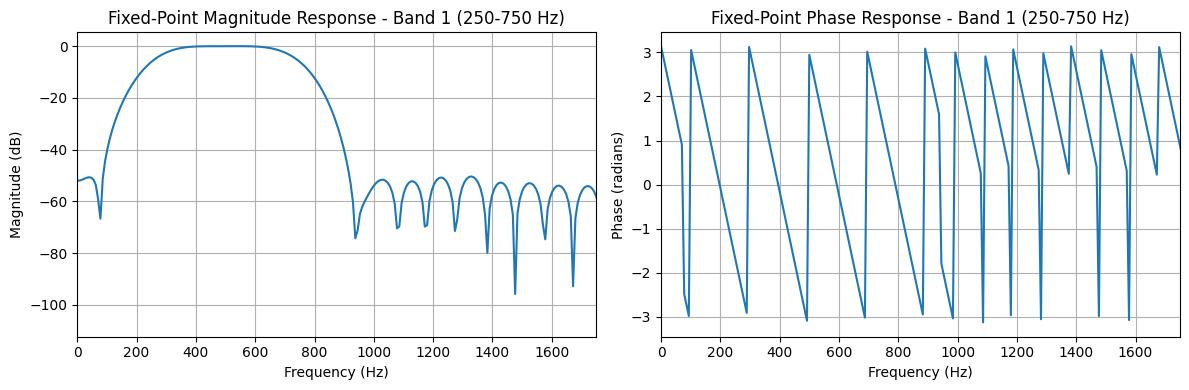

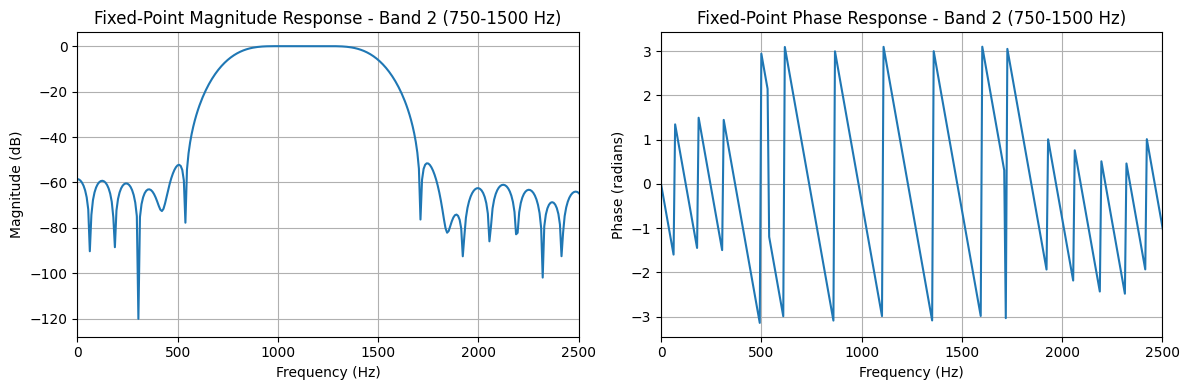

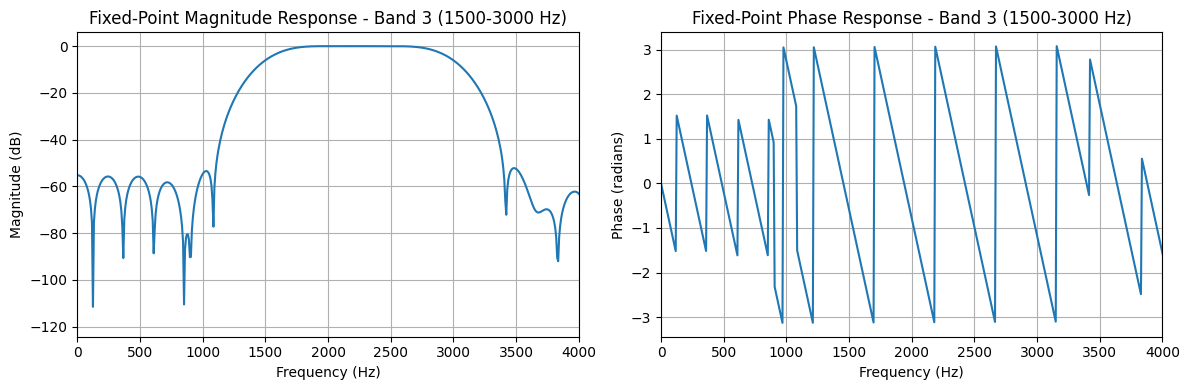

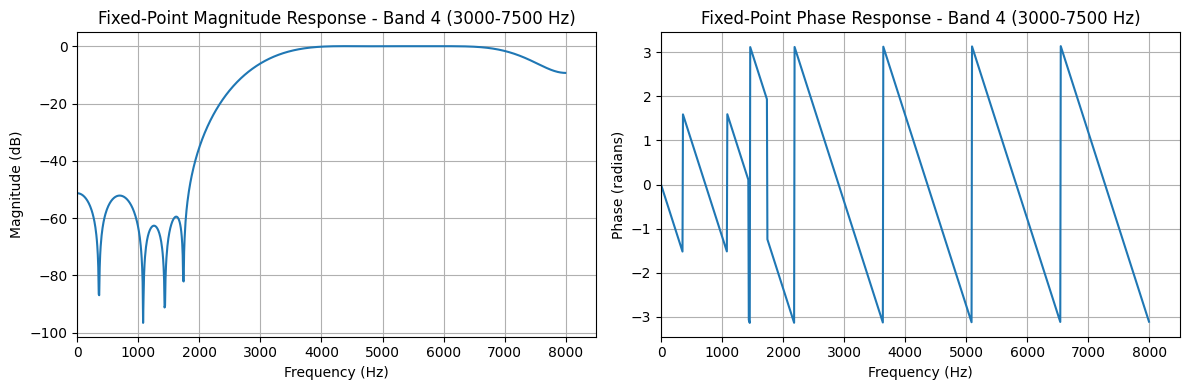

In [15]:
num_bands = len(filters_fir_fixed)
# gains = [1, 1, 1, 1, 1, 8, 1, 1]

# # Compute sum of absolute coefficients for each band
# H = [np.sum(np.abs(filters_fir_fixed[k])) for k in range(num_bands)]

# # Total weighted sum
# S = sum(gains[k] * H[k] for k in range(num_bands))

# # Desired headroom (e.g., 0.85)
# desired_headroom = 0.85

# # Compute OUTPUT_SCALE
# OUTPUT_SCALE = desired_headroom / S

# print("OUTPUT_SCALE =", OUTPUT_SCALE)

for k in range(num_bands):
    filt_fxp = filters_fir_fixed[k]
    w, h = freqz(filt_fxp, worN=1024, fs=fs)

    plt.figure(figsize=(12, 4))

    # Magnitude response
    plt.subplot(1, 2, 1)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-10), linewidth=1.5)
    plt.grid(True)
    plt.xlim(0, bands[k,1] + 1000)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"Fixed-Point Magnitude Response - Band {k+1} ({bands[k,0]}-{bands[k,1]} Hz)")

    # Phase response
    plt.subplot(1, 2, 2)
    plt.plot(w, np.angle(h), linewidth=1.5)
    plt.grid(True)
    plt.xlim(0, bands[k,1] + 1000)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase (radians)")
    plt.title(f"Fixed-Point Phase Response - Band {k+1} ({bands[k,0]}-{bands[k,1]} Hz)")

    plt.tight_layout()
    plt.show()


We will analyze Band 3 1500-3000Hz by evaluating its spectrogram after filtering both from python simulation and HLS simulation

In [19]:
# Apply all bands with gains in fixed-point approximation
target_band = 3  # Band 3 for analysis

y = np.zeros_like(x_left_quant)

gain_target = 10 #gain in the targeted frequency band
gain_other = 1.0  # 0 dB gain remaining band

for k in range(num_bands):
    filt_fxp = filters_fir_fixed[k]
    y_band = lfilter(filt_fxp, 1.0, x_left_quant)
    if k + 1 == target_band:
        y += y_band * gain_target
    else:
        y += y_band * gain_other

0.028445747680962086


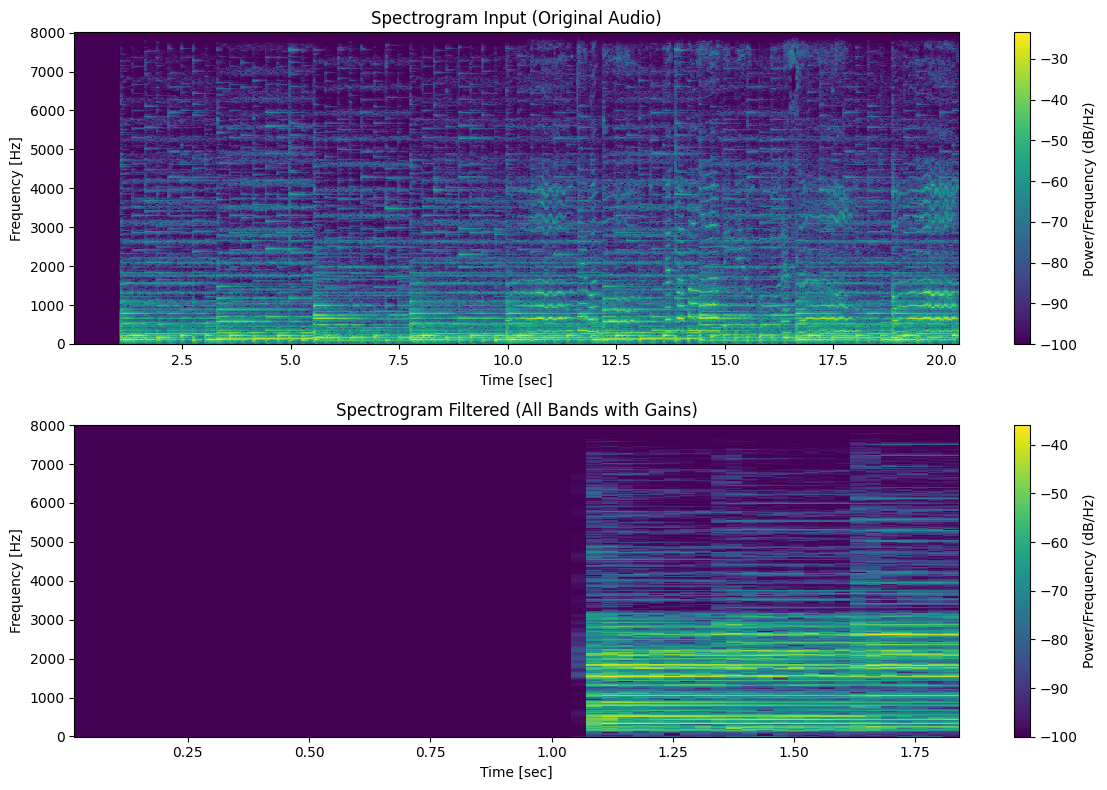

In [20]:
# Plot spectrograms
f, t, Sxx_in = spectrogram(x_left, fs=fs, nperseg=1024, noverlap=512)

plt.figure(figsize=(12, 8))

plt.subplot(2,1,1)
plt.pcolormesh(t, f, 10 * np.log10(Sxx_in + 1e-10))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Input (Original Audio)')
plt.colorbar(label='Power/Frequency (dB/Hz)')

f, t, Sxx_out = spectrogram(y[0:30000], fs=fs, nperseg=1024, noverlap=512)
print(y[22345])

plt.subplot(2,1,2)
plt.pcolormesh(t, f, 10 * np.log10(Sxx_out + 1e-10))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Filtered (All Bands with Gains)')
plt.colorbar(label='Power/Frequency (dB/Hz)')

plt.tight_layout()
plt.show()

#### After simulation from HLS, the filtered samples are exported and its spectrogram is plotted for analysis.

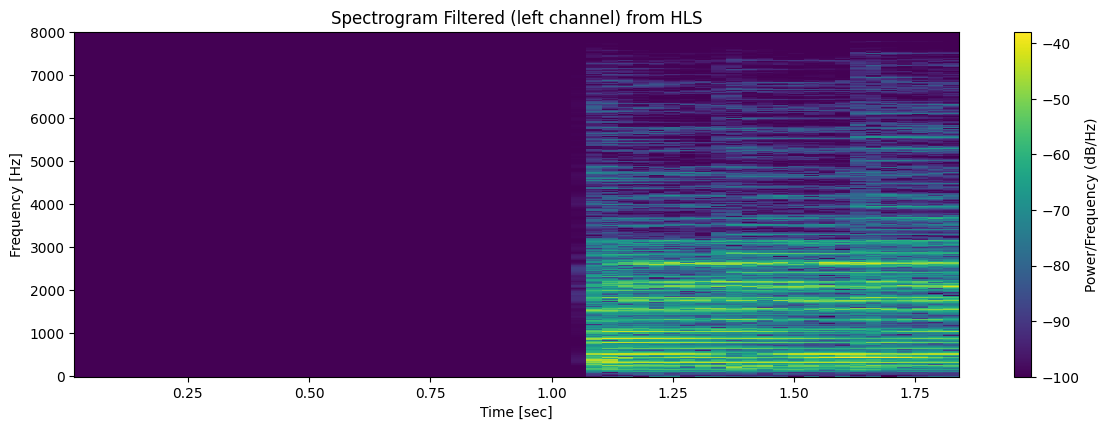

In [25]:
# data = np.loadtxt(r"data/filtered_stereo.txt")
data = np.loadtxt(r"C:\Users\thebi\Desktop\MAJOR_PROJECT\SRC\HLS_Simulations\filterbanks\four_bands_filterbank\four_bands_filterbank\hls\csim\build\filtered_stereo.txt")
sr=16000
left = data[:,1]   # left channel

f, t, Sxx_in = spectrogram(left, fs=sr, nperseg=1024, noverlap=512)

plt.figure(figsize=(12, 8))

plt.subplot(2,1,2)
plt.pcolormesh(t, f, 10 * np.log10(Sxx_in + 1e-10))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Filtered (left channel) from HLS')
plt.colorbar(label='Power/Frequency (dB/Hz)')

plt.tight_layout()
plt.show()
